In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report,confusion_matrix, accuracy_score)

In [8]:
df = pd.read_csv("people_movie_interest_1.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (6000, 35)

First 5 Rows:
   person_id            age_group  gender personality_type  mood_score  \
0          1         Teen (13-17)    Male         Ambivert         6.0   
1          2  Young Adult (18-25)  Female        Extrovert         7.5   
2          3  Young Adult (18-25)    Male         Ambivert         7.2   
3          4         Teen (13-17)    Male        Introvert         5.2   
4          5         Teen (13-17)    Male        Introvert         6.3   

   stress_level                        hobbies favorite_game_genre  \
0           4.5                          Music          Simulation   
1           5.8             Reading, Traveling     Horror/Survival   
2           6.9  Fitness, Painting/Art, Gaming              Puzzle   
3           2.5  Painting/Art, Writing, Sports              Puzzle   
4           8.8                        Cooking              Puzzle   

  favorite_music_genre  fear_tolerance  ...  snack_preference  \
0                Indie      

In [9]:
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())


Missing Values:
person_id                         0
age_group                         0
gender                            0
personality_type                  0
mood_score                        0
stress_level                      0
hobbies                           0
favorite_game_genre             360
favorite_music_genre            356
fear_tolerance                    0
risk_tolerance                    0
humor_preference                  0
openness_score                    0
romance_interest                  0
social_media_hours_per_day        0
preferred_language                0
relationship_status               0
favorite_season                   0
sleep_pattern                     0
education_level                   0
occupation                        0
income_bracket                    0
preferred_streaming_platform      0
preferred_watch_time              0
viewing_companion                 0
snack_preference                  0
preferred_device                  0
preferred_m

In [10]:
X = df.drop("recommended_movie_genre", axis=1)
y = df["recommended_movie_genre"]

# Remove ID column because it is not useful
X = X.drop("person_id", axis=1)


In [11]:

X = pd.get_dummies(X, drop_first=True)

# Convert True/False to 0/1
X = X.astype(float)

In [12]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("\nMovie Genre Classes:")
print(label_encoder.classes_)


Movie Genre Classes:
['Action' 'Animation' 'Comedy' 'Documentary' 'Drama' 'Horror' 'Romance'
 'Sci-Fi' 'Thriller']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# --------------------------------------------
# 7. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Training Data: (4800, 1635)
Testing Data: (1200, 1635)


In [15]:

model = MLPClassifier(
    hidden_layer_sizes=(50, 50, 10),
    max_iter=1000,
    random_state=42,
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.01,
    momentum=0.9
)

In [16]:
model.fit(X_train, y_train)

print("\nMLP Model Training Completed!")


MLP Model Training Completed!


In [17]:
y_pred = model.predict(X_test)


In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("\n====================================")
print("MLP CLASSIFICATION RESULTS")
print("====================================")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")


MLP CLASSIFICATION RESULTS

Accuracy: 0.1683
Accuracy Percentage: 16.83%


In [19]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


Classification Report:
              precision    recall  f1-score   support

      Action       0.17      0.99      0.29       203
   Animation       0.00      0.00      0.00        88
      Comedy       0.00      0.00      0.00       117
 Documentary       0.00      0.00      0.00       126
       Drama       0.00      0.00      0.00       198
      Horror       0.00      0.00      0.00        74
     Romance       0.00      0.00      0.00       111
      Sci-Fi       0.00      0.00      0.00        80
    Thriller       0.17      0.00      0.01       203

    accuracy                           0.17      1200
   macro avg       0.04      0.11      0.03      1200
weighted avg       0.06      0.17      0.05      1200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


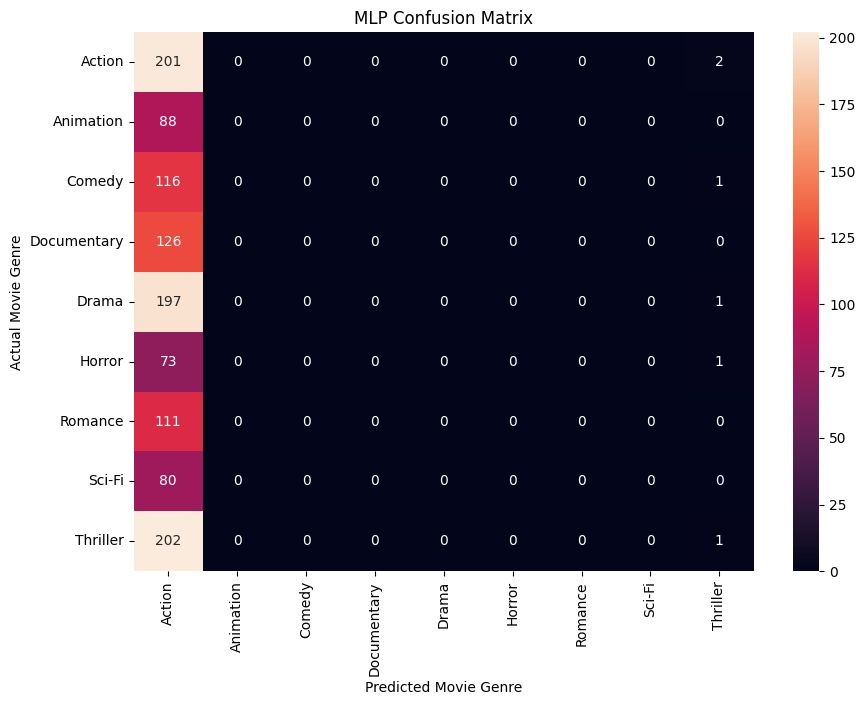

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Movie Genre")
plt.ylabel("Actual Movie Genre")
plt.title("MLP Confusion Matrix")

plt.show()

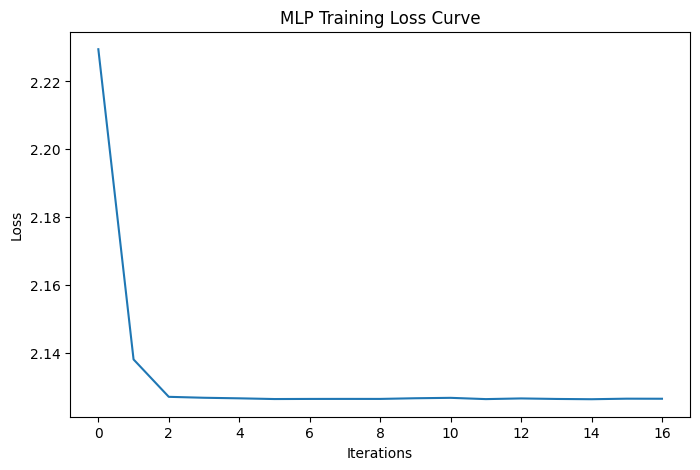

In [21]:

plt.figure(figsize=(8, 5))

plt.plot(model.loss_curve_)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")

plt.show()